# QA Evaluation - comparing LoRA/QLoRA configurations

This notebook compares the experimental configurations from the report on a subset of the SQuAD validation set, using **Exact Match (EM)** and **token-level F1**. Every
configuration is loaded from a merged checkpoint on disk via the `Inference` wrapper.

In [31]:
import sys, os
sys.path.append('..')

import re
import string
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
from safetensors.torch import load_file

from inference import Inference

## 1. Configurations to compare

Map each report experiment to its merged checkpoint on disk. Adjust the experiment folder /
file names to match your runs (the training script saves
`checkpoint_merged_{lora|qlora}_{epoch}.safetensors`).

In [32]:
WORK_DIR = os.path.join('..', 'work_dir')

CONFIGS = {
    'Exp 1 - LoRA r=8':        'LoRA_RoBERTa_QA/checkpoints/checkpoint_merged_lora_3.safetensors',
    'Exp 2 - QLoRA r=8 (NF4)': 'QLoRA_RoBERTa_QA/checkpoints/checkpoint_merged_qlora_3.safetensors',
    'Exp 3a - LoRA r=4':       'LoRA_RoBERTa_QA_r4/checkpoints/checkpoint_merged_lora_3.safetensors',
    'Exp 3b - LoRA r=16':      'LoRA_RoBERTa_QA_r16/checkpoints/checkpoint_merged_lora_3.safetensors',
}
CONFIGS = {name: os.path.join(WORK_DIR, rel) for name, rel in CONFIGS.items()}

available = {name: p for name, p in CONFIGS.items() if os.path.isfile(p)}

## 2. SQuAD validation subset

Loaded once and reused for every configuration so the comparison is apples-to-apples.

In [33]:
NUM_EXAMPLES = 500  # set to None for the full validation split

squad_val = load_dataset('squad', split='validation')
if NUM_EXAMPLES is not None:
    squad_val = squad_val.select(range(min(NUM_EXAMPLES, len(squad_val))))
print(f'Evaluating each configuration on {len(squad_val)} examples')

Evaluating each configuration on 500 examples


## 3. SQuAD metrics

In [34]:
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in set(string.punctuation))
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))


def compute_exact(gold, pred):
    return int(normalize_answer(gold) == normalize_answer(pred))


def compute_f1(gold, pred):
    gold_toks = normalize_answer(gold).split()
    pred_toks = normalize_answer(pred).split()
    common = Counter(gold_toks) & Counter(pred_toks)
    num_same = sum(common.values())
    if len(gold_toks) == 0 or len(pred_toks) == 0:
        return int(gold_toks == pred_toks)
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_toks)
    recall = num_same / len(gold_toks)
    return 2 * precision * recall / (precision + recall)


def max_over_golds(metric_fn, golds, pred):
    return max(metric_fn(g, pred) for g in golds)

## 4. Evaluate each configuration

The model is built once; for each configuration we only swap the
weights with `load_state_dict(load_file(path))`, then score the same validation subset.

In [35]:
inference = Inference()
inference.load_model(next(iter(available.values())))  # build model + tokenizer once


def evaluate_checkpoint(weights_path):
    inference.model.load_state_dict(load_file(weights_path))
    inference.model.eval()
    rows = []
    for ex in squad_val:
        golds = ex['answers']['text']
        _, _, pred = inference.predict(ex['question'], ex['context'])
        rows.append({
            'gold': golds[0],
            'prediction': pred,
            'EM': max_over_golds(compute_exact, golds, pred),
            'F1': max_over_golds(compute_f1, golds, pred),
        })
    return pd.DataFrame(rows)


per_config = {}
summary = []
for name, path in tqdm(available.items(), desc='configs'):
    df = evaluate_checkpoint(path)
    per_config[name] = df
    summary.append({
        'config': name,
        'n': len(df),
        'EM': round(100.0 * df['EM'].mean(), 2),
        'F1': round(100.0 * df['F1'].mean(), 2),
    })

summary = pd.DataFrame(summary).set_index('config')
summary

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


configs:   0%|          | 0/4 [00:00<?, ?it/s]

,n,EM,F1
config,,,
Exp 1 - LoRA r=8,500,82.0,86.79
Exp 2 - QLoRA r=8 (NF4),500,83.4,87.29
Exp 3a - LoRA r=4,500,77.8,83.45
Exp 3b - LoRA r=16,500,86.6,89.61


## 5. Comparison chart

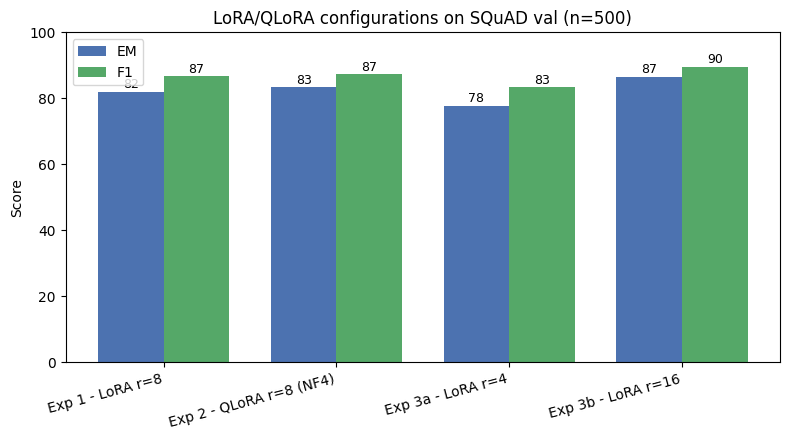

In [36]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(summary))
w = 0.38
ax.bar(x - w/2, summary['EM'], w, label='EM', color='#4C72B0')
ax.bar(x + w/2, summary['F1'], w, label='F1', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 100)
ax.set_title(f'LoRA/QLoRA configurations on SQuAD val (n={len(squad_val)})')
ax.legend()
for i, (em, f1) in enumerate(zip(summary['EM'], summary['F1'])):
    ax.text(i - w/2, em + 1, f'{em:.0f}', ha='center', fontsize=9)
    ax.text(i + w/2, f1 + 1, f'{f1:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eval_scores.png', dpi=150)
plt.show()

## 6. Per-example F1 distribution by configuration

F1 tends to be bimodal (spikes near 0.0 for misses and 1.0 for exact spans), so the full
distribution is more informative than the mean alone. Grouped histogram, one colour per
configuration.

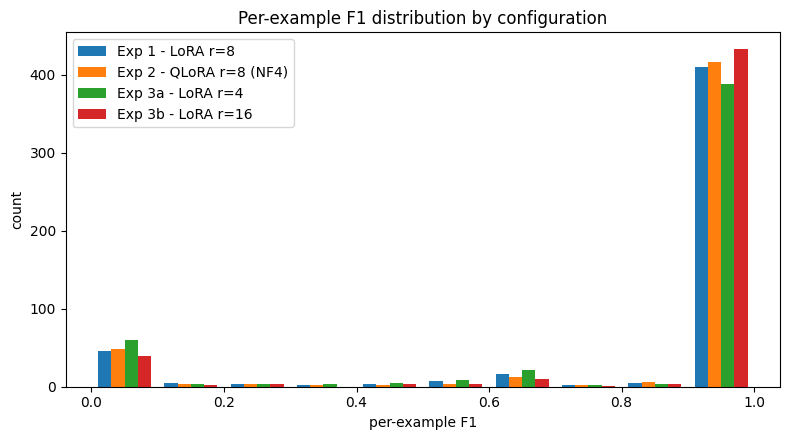

In [38]:
labels = list(per_config)
data = [per_config[name]['F1'].values for name in labels]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(data, bins=10, range=(0, 1), label=labels)
ax.set_xlabel('per-example F1')
ax.set_ylabel('count')
ax.set_title('Per-example F1 distribution by configuration')
ax.legend()
plt.tight_layout()
plt.savefig('f1_distributions.png', dpi=150)
plt.show()